### This project involves training a machine learning model to predict crop production in Kenya using the Distribution of Crop Production dataset from Kaggle. It utilizes Random Forest Regressor and K-means algorithms to predict crop production based on various features and group counties by crop production profile. Finally, the performance of the models is evaluated using R-squared and Mean Squared Error metrics.

In [11]:
# Imports and reproducibility setup
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score

Download, explore and preprocess the data

In [2]:
#download the dataset
path = kagglehub.dataset_download("osiroski/distirbution-of-crop-production-kenya-2019-census")
print("Path to dataset files:", path)

#load and explore the dataset
from pathlib import Path

csv_files = list(Path(path).glob("*.csv"))
print(csv_files)

data = pd.read_csv(csv_files[0])
data.head()

Path to dataset files: C:\Users\chalo\.cache\kagglehub\datasets\osiroski\distirbution-of-crop-production-kenya-2019-census\versions\4
[WindowsPath('C:/Users/chalo/.cache/kagglehub/datasets/osiroski/distirbution-of-crop-production-kenya-2019-census/versions/4/distribution-of-households-growing-other-crops-by-type-county-and-sub-county-2019-census-volume-.csv')]


,County/Sub County,Total,Farming,Crop Production,Livestock Production,Aquaculture,Fishing,Irrigation,Maize,Sorghum,...,Camels,Donkeys,Pigs,Indigenous Chicken,Exotic Chicken Layers,Exotic Chicken Broilers,Beehives,Rabbits,Fish Ponds,Fish Cages
0,KENYA,12143913,6354211.0,5555974,4729288,29325,109640,369679,5104967.0,904945.0,...,167666.0,500682,110383.0,3337700,194517,79461,201406,124122,22019.0,3361.0
1,MOMBASA,378422,12497.0,7218,8749,128,1409,958,5681.0,NaN,...,6.0,36,134.0,6142,743,998,68,186,83.0,24.0
2,CHANGAMWE,46614,618.0,230,476,6,62,36,108.0,NaN,...,0.0,1,7.0,350,53,78,1,14,6.0,0.0
3,JOMVU,53472,2418.0,1168,1810,12,132,209,895.0,NaN,...,0.0,11,37.0,1296,157,199,6,30,8.0,3.0
4,KISAUNI,88202,6257.0,4043,4269,67,492,402,3456.0,NaN,...,4.0,8,76.0,3016,280,411,41,79,37.0,11.0


In [3]:
# Prepare a complete numeric modelling dataset
df_model = data.copy()

# Fill missing values with median
numeric_columns = df_model.select_dtypes(include=np.number).columns
df_model[numeric_columns] = df_model[numeric_columns].apply(pd.to_numeric, errors="coerce")
df_model[numeric_columns] = df_model[numeric_columns].fillna(df_model[numeric_columns].median())

print(f"Rows: {len(df_model)}, columns: {df_model.shape[1]}")
print(f"Remaining missing numeric values: {df_model[numeric_columns].isna().sum().sum()}")

Rows: 393, columns: 42
Remaining missing numeric values: 0


In [4]:
# Inspect the cleaned data
df_model.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
Total,393.0,92701.625954,619672.291179,11.0,21947.0,33025.0,50704.0,12143913.0
Farming,393.0,48611.524173,322383.892199,2.0,12241.0,20848.0,28514.0,6354211.0
Crop Production,393.0,74078.412214,686966.532963,0.0,8461.0,18984.0,25732.0,12457351.0
Livestock Production,393.0,36101.435115,239841.989092,0.0,9128.0,15379.0,20749.0,4729288.0
Aquaculture,393.0,223.854962,1492.418005,0.0,40.0,77.0,137.0,29325.0


In [5]:
# Remove the national aggregate: it is not comparable to a county/sub-county row.
model_data = df_model[
    df_model["County/Sub County"].str.upper().ne("KENYA")
].copy()

target_column = "Crop Production"
excluded_columns = [target_column, "County/Sub County", "Total"]

#split the data into features and target variables
X = model_data.drop(columns=excluded_columns)
y = model_data[target_column]

# Log-transform the highly skewed target for more stable regression.
y_log = np.log1p(y)

#split the data into training and testing sets
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=117)

y_test = np.expm1(y_test_log)

print(f"Rows used: {len(model_data)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train_log.shape}, y_test: {y_test.shape}")

Rows used: 392
X_train: (313, 39), X_test: (79, 39)
y_train: (313,), y_test: (79,)


**Implement Random Forest Regressor**

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation MSE on log scale: 0.5190

Tuned Random Forest Regressor performance
R-squared: 0.9815
Mean Squared Error: 24459939.01


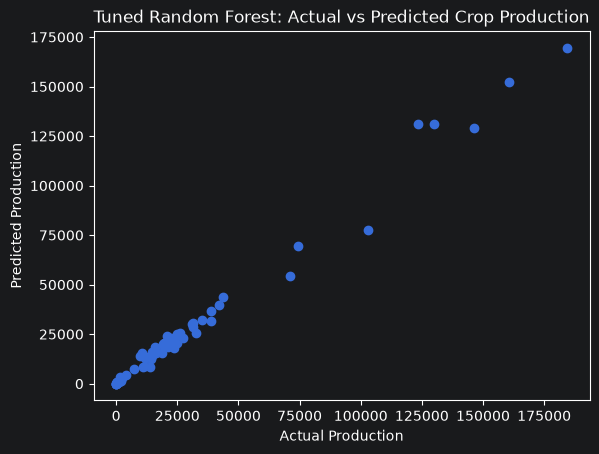

In [12]:
# Tune the Random Forest with GridSearchCV
rf_base = RandomForestRegressor(random_state=117, n_jobs=-1)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [1.0, "sqrt"]
}

# chose GridSearchCV over RandomizedSearchCV because the data is relatively small.
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, scoring="neg_mean_squared_error", cv=5, n_jobs=-1, refit=True, verbose=1)
grid_search.fit(X_train, y_train_log)

rf_model = grid_search.best_estimator_

# Convert predictions back to the original production scale.
y_pred = np.expm1(rf_model.predict(X_test))

# Evaluate the model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validation MSE on log scale: {-grid_search.best_score_:.4f}")
print()
print("Tuned Random Forest Regressor performance")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Tuned Random Forest: Actual vs Predicted Crop Production")
plt.show()

**Implement K-means clustering to group counties/sub-counties by crop production profile**

Silhouette scores: {2: 0.21058449663554518, 3: 0.2091948356790559, 4: 0.16562161113341628, 5: 0.1751653129440825, 6: 0.1658270322419978, 7: 0.13270992964114078}
Selected k: 2
Cluster
0    271
1    121
Name: count, dtype: int64


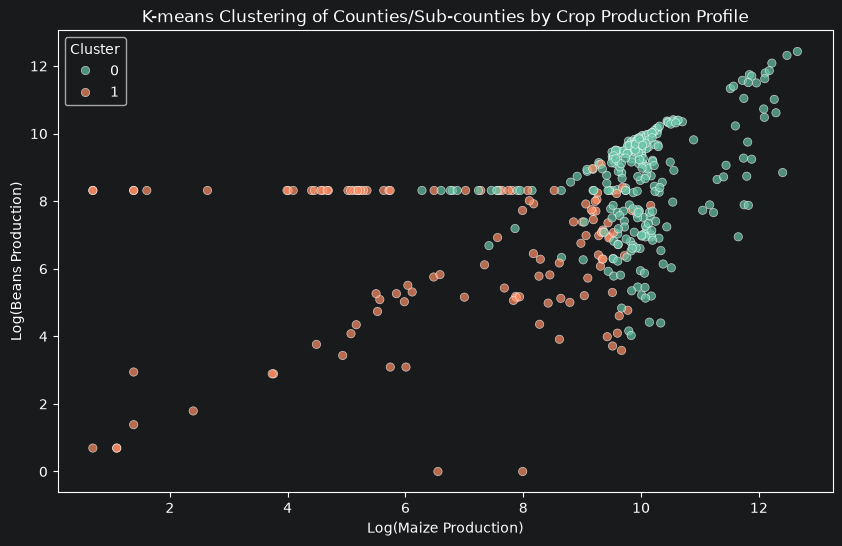

In [10]:
# Cluster counties/sub-counties by crop-production profile
crop_columns = [
    "Maize", "Sorghum", "Rice", "Potatoes", "Beans", "Cassava",
    "Sweet Potatoes", "Wheat", "Green grams", "Bananas", "Cabbages",
    "Tomatoes", "Onions", "Ground Nuts", "Millet", "Watermelons",
    "Kales", "Sugarcane", "Cotton"
]

crop_data = np.log1p(model_data[crop_columns])
scaler = StandardScaler()
crop_scaled = scaler.fit_transform(crop_data)

# Select k using the silhouette score rather than assuming one value.
candidate_k = range(2, 8)
silhouette_scores = {}
for k in candidate_k:
    candidate_model = KMeans(n_clusters=k, random_state=117, n_init=20)
    candidate_labels = candidate_model.fit_predict(crop_scaled)
    silhouette_scores[k] = silhouette_score(crop_scaled, candidate_labels)

n_clusters = max(silhouette_scores, key=silhouette_scores.get)
kmeans_model = KMeans(
    n_clusters=n_clusters,
    random_state=117,
    n_init=20
)
cluster_labels = kmeans_model.fit_predict(crop_scaled)

clustered_data = model_data[["County/Sub County"]].copy()
clustered_data["Cluster"] = cluster_labels

print("Silhouette scores:", silhouette_scores)
print(f"Selected k: {n_clusters}")
print(clustered_data["Cluster"].value_counts().sort_index())
clustered_data.head()

# plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=crop_data["Maize"], y=crop_data["Beans"], hue=cluster_labels, palette="Set2", alpha=0.7)
plt.title("K-means Clustering of Counties/Sub-counties by Crop Production Profile")
plt.xlabel("Log(Maize Production)")
plt.ylabel("Log(Beans Production)")
plt.legend(title="Cluster")
plt.show()